In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize_scalar

### Luokkien määrittely

In [2]:
class Transmon:

    def __init__(self,E_C,E_J,N):

        self.E_C=E_C #Varausenergia
        self.E_J=E_J #Josephsonin energia
        self.N=N   

        self.phi = np.linspace(-np.pi, np.pi, N, endpoint=False) #vaiheoperaattori diskretisoituna välillä [-pi,pi] 1000 pisteeseen
        self.delta_phi = self.phi[2]-self.phi[1] #vaiheoperaattorin diskresitoitu askelväli

        M = np.eye(N,k=1)+np.eye(N,k=-1)-2*np.eye(N) #Muodostetaan numero-operaattorin neliön matriisiesitys differenssimenetelmällä
        M[0,-1]=1
        M[-1,0]=1
        n_squared = -M/(self.delta_phi**2)

        self.H_0 = 4*E_C*n_squared-E_J*np.diag(np.cos(self.phi)) #Hamiltonin operaattori

        energies, eigenstates = np.linalg.eigh(self.H_0) # Transmonin ominaisenergiat ja -tilat

        self.energies = energies #Ominaisenergiat
        self.eigenstates = eigenstates #Ominaistilat
        self.frequency = energies[1]-energies[0] #Kubitin taajuus
    
    def H_D_eigbasis(self,dim): #Ajettu Hamiltonin operaattori ominaiskannassa
 
        H_0 = np.diag(self.energies[0:dim]-self.energies[0]) #Diagonaalimatriisi ominaisenergioista (lukumäärä ensimmäiset dim)

        M = np.zeros((dim, dim))
        vals = np.sqrt(np.arange(1, dim))
        M[np.arange(dim-1), np.arange(1, dim)] = vals      
        M[np.arange(1, dim), np.arange(dim-1)] = vals

        def H_t(A): return H_0 + A*M

        return H_t
    
class time_evolution:

    def __init__(self,generator):
        self.generator = generator
    
    def U(self, A, dt): return expm(-1j * self.generator(A) * dt) #Aikaevoluutio-operaattori

    def U_floquet(self, A_vals, dt): #Floquet-operaattori

        U_f = self.U(0, 0) #Aikakehitysoperaattori yhdelle Floquet-jaksolle
        for A in A_vals: 
            U_f = self.U(A, dt) @ U_f
        return U_f

class Pulse:

    def __init__(self,frequency,pulse_funcs,pulse_times,time_unit=1):

        #Tarkistetaan, että on annettu sama määrä pulssifunktiota ja -aikoja
        if len(pulse_times)!=len(pulse_funcs):
            raise Exception("Pulse function and time interval arrays must have the same size") 

        #Määritellään ajan arvot eri pulssin osille
        piecewise_time_vals=[(np.arange(time)*time_unit) for time in pulse_times]

        #Ajan arvot koko pulssin ajalle
        self.time_vals = np.arange(np.sum(pulse_times))*time_unit

        #Pulssin amplitudi määriteltynä kolmessa osassa
        piecewise_pulse_vals=[np.array([pulse_funcs[i](t) for t in piecewise_time_vals[i]]) for i in range(0,len(piecewise_time_vals))]

        #Pulssin amplitudi
        self.envelope = np.concatenate(piecewise_pulse_vals)
        
        #Määritellään signaalin vaihe siten, että amplitudi on nolla keskimmäisen jakson alussa
        #offset=frequency*pulse_times[0]
        offset=0

        #Signaali ajotaajuudella
        signal = np.array([np.sin(frequency*t-offset) for t in self.time_vals])

        #Signaalin arvot moduloituna amplitudilla
        self.raw = self.envelope*signal        

        self.freqs = np.fft.rfftfreq(len(self.time_vals), d=time_unit) #Taajuusavaruus diskretoituna time_unit välein

        #Fourier-muunnos signaalista
        self.fourier = np.fft.rfft(self.raw) 

### Funktioita pulssimuotojen muodostamiseen

In [3]:
def zero(t): #Nollafunktio
    return 0

def one(t): #Ykkösfunktio
    return 1

def arctan(t_0,c): #Arkustangentti skaalattuna välille [-1,1], siirrettynä t_0 verran ajassa
    return lambda t: np.arctan(c*(t-t_0))/np.pi+0.5

def arctan_opp(t_0,c): #Arkustangentti -t-funktiona, siirrettynä -t_0 verran ajassa. Pulssin laskevaa reunaa varten
    return lambda t: np.arctan(c*(t_0-t))/np.pi+0.5

def gaussian(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä t_0.
    return lambda t: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((t-t_0)**2)/(2*sigma**2))
    
def gaussian_opp(t_0,sigma): #Normalisoitu Gaussinen funktio keskihajonnalla sigma, ja keskipisteellä -t_0. Pulssin laskevaa reunaa varten
    return lambda t: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-((t+t_0)**2)/(2*sigma**2))

### Transmonin määrittely

In [4]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=Transmon(E_C,E_J,500)

In [5]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


In [6]:
A = 0.2*qubit.frequency #Ajava amplitudi
AC_stark=-0.0085 #AC-stark siirtymä

f_d = qubit.frequency/3+AC_stark #Ajotaajuus
f_rabi = 0.000244574 #Rabi-taajuus

T = 1/(2*f_rabi)

f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

print(f_d)
print(f_ef)
print(T)

1.3437123012121608
3.6735669474914276
2044.3710288092766


In [250]:
T_1=2.15
T_2=T-T_1

In [251]:
T_g=22.85

## Simulaatio

In [252]:
N = 8000
N_1=int(N*T_1/T)
N_2=N-N_1

dt=T/(N) #Aikayksikö/kahden aikapisteen välinen aika
N_g=int(T_g/dt)

N_vals = [10000,N_1,N_g,N_2+N,10000]
funcs = [zero,one,zero,one,zero]

N_tot = np.sum(N_vals)

In [253]:
print(N_g)

89


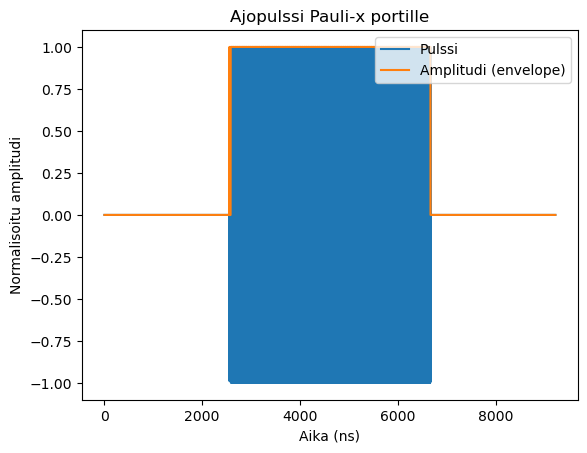

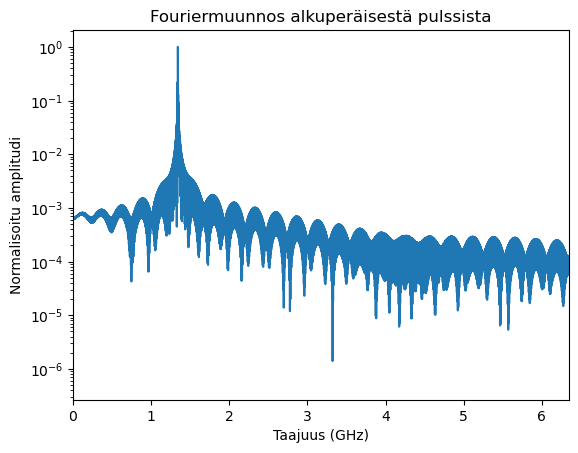

In [254]:
#Kanttipulssi muodostettuna kahdesta vastakkaisesta arkustangenttifunktiosta symmetrisesti pulssin keskipisteen suhteen
square_pulse = Pulse(f_d,funcs,N_vals,time_unit=dt)

fig1=plt.figure()
plt.plot(square_pulse.time_vals,square_pulse.raw)
plt.plot(square_pulse.time_vals,square_pulse.envelope)
plt.xlabel("Aika (ns)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Ajopulssi Pauli-x portille")
plt.legend(["Pulssi","Amplitudi (envelope)"], loc = 'upper right')
plt.show()

fig2=plt.figure()
plt.semilogy(square_pulse.freqs*2*np.pi, np.abs(square_pulse.fourier)/np.max(np.abs(square_pulse.fourier)))
plt.xlim([0,f_d+5])
plt.xlabel("Taajuus (GHz)")
plt.ylabel("Normalisoitu amplitudi")
plt.title("Fouriermuunnos alkuperäisestä pulssista")
plt.show()

In [255]:
dim = 7

evolution_eigenbasis=time_evolution(qubit.H_D_eigbasis(dim))

In [256]:
#Simulaatio ominaiskannassa

psi_eig = np.zeros((N_tot, dim), dtype=complex) #Alustetaan kubitin tila perustilaan
psi_eig[0,0] = 1

for i in range(1, N_tot): #Aikakehitys
    psi_eig[i] = evolution_eigenbasis.U(A*square_pulse.raw[i], dt) @ psi_eig[i-1]

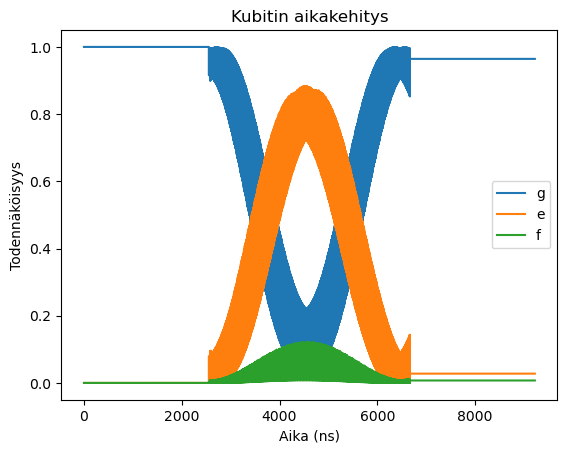

In [257]:
prob_g = np.abs(psi_eig[:, 0])**2
prob_e = np.abs(psi_eig[:, 1])**2
prob_f = np.abs(psi_eig[:, 2])**2

plt.plot(square_pulse.time_vals,prob_g)
plt.plot(square_pulse.time_vals,prob_e)
plt.plot(square_pulse.time_vals,prob_f)
plt.xlabel("Aika (ns)")
plt.ylabel("Todennäköisyys")
plt.title("Kubitin aikakehitys")
plt.legend(['g','e','f'])

In [258]:
print("Tasojen lopulliset todennäköisyydet (g,e,f):")
print(prob_g[-1])
print(prob_e[-1])
print(prob_f[-1])

Tasojen lopulliset todennäköisyydet (g,e,f):
0.9644157436754959
0.027630076331846765
0.007252782564182054


In [259]:
print(np.max(prob_e))

0.8837449316298193
